# Optimism WBTC/WETH Exploration

This notebook is a market-expansion notebook for **WBTC/WETH on Optimism**.

It is designed to answer one question before you spend more time on engineering: **could this market produce better post-cost arbitrage economics than the current Ethereum `WBTC/WETH` setup?**

Why this variant is worth testing:
- Optimism provides another lower-fee EVM environment for the same core arbitrage design.
- It is useful as a second L2 comparison so you do not confuse one chain-specific liquidity profile with a general result.
- If both Arbitrum and Optimism look weak after cost assumptions, the issue is more likely the pair structure than the chain fee layer.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

MARKET_SPEC = {'slug': 'optimism_wbtc_weth', 'scope_type': 'chain expansion', 'chain_family': 'EVM', 'chain_name': 'Optimism', 'pair': 'WBTC/WETH', 'base_token': 'WBTC', 'quote_token': 'WETH', 'goal': 'Test whether lower chain fees can rescue a volatile-pair arbitrage setup.', 'hypothesis': 'Lower execution costs may allow modest WBTC/WETH spreads to remain net positive more often than on mainnet.', 'pipeline_fit': 'Medium. The EVM event model still fits, but RPC, gas accounting, venue discovery, and liquidity assumptions all need to change.', 'output_prefix': 'optimism_wbtc_weth', 'work_items': [{'area': 'RPC + blocks', 'change_needed': 'Replace mainnet RPC assumptions with Optimism RPC and block/timestamp collection.', 'priority': 'high'}, {'area': 'Venue discovery', 'change_needed': 'Choose and verify two Optimism venues plus the exact pool addresses for WBTC/WETH.', 'priority': 'high'}, {'area': 'Gas model', 'change_needed': 'Swap mainnet base-fee logic for an L2-specific transaction-cost model.', 'priority': 'high'}, {'area': 'Outputs', 'change_needed': 'Write Optimism artifacts into dedicated raw, curated, and report folders.', 'priority': 'medium'}, {'area': 'Interpretation', 'change_needed': 'Check whether liquidity depth is sufficient for the trade sizes you care about.', 'priority': 'medium'}]}
ASSUMPTIONS = {'trade_notional_usd': 10000, 'fee_tiers_bps': [5, 30], 'gas_cost_usd_scenarios': {'optimistic': 0.1, 'base': 0.5, 'stress': 1.5}, 'slippage_buffer_bps': 12, 'spread_grid_bps': [5, 10, 20, 40, 80]}

summary_rows = [
    {'field': 'scope_type', 'value': MARKET_SPEC['scope_type']},
    {'field': 'chain_family', 'value': MARKET_SPEC['chain_family']},
    {'field': 'chain_name', 'value': MARKET_SPEC['chain_name']},
    {'field': 'pair', 'value': MARKET_SPEC['pair']},
    {'field': 'base_token', 'value': MARKET_SPEC['base_token']},
    {'field': 'quote_token', 'value': MARKET_SPEC['quote_token']},
    {'field': 'notebook_goal', 'value': MARKET_SPEC['goal']},
    {'field': 'main_hypothesis', 'value': MARKET_SPEC['hypothesis']},
    {'field': 'current_pipeline_fit', 'value': MARKET_SPEC['pipeline_fit']},
    {'field': 'suggested_output_prefix', 'value': MARKET_SPEC['output_prefix']},
]

display(pd.DataFrame(summary_rows))
display(Markdown(
    f"This notebook is a **scoping notebook**, not a claim that `02_end_to_end_mev_pipeline.ipynb` can run unchanged for {MARKET_SPEC['pair']} on {MARKET_SPEC['chain_name']}. "
    "Use it to test whether lower gas, lower LP fees, or better market structure could make the economics more attractive before doing the heavier engineering work."
))

,field,value
0,scope_type,chain expansion
1,chain_family,EVM
2,chain_name,Optimism
3,pair,WBTC/WETH
4,base_token,WBTC
5,quote_token,WETH
6,notebook_goal,Test whether lower chain fees can rescue a vol...
7,main_hypothesis,Lower execution costs may allow modest WBTC/WE...
8,current_pipeline_fit,"Medium. The EVM event model still fits, but RP..."
9,suggested_output_prefix,optimism_wbtc_weth


This notebook is a **scoping notebook**, not a claim that `02_end_to_end_mev_pipeline.ipynb` can run unchanged for WBTC/WETH on Optimism. Use it to test whether lower gas, lower LP fees, or better market structure could make the economics more attractive before doing the heavier engineering work.

## Break-Even Spread Scenarios

The table below is intentionally simple. It treats the market as viable only when the observable cross-venue spread is larger than:

`round-trip DEX fees + gas cost + a slippage buffer`

The assumptions are editable. The point is not to forecast exact live profitability, but to see whether this market still looks plausible after costs.

In [2]:
fee_tiers_bps = ASSUMPTIONS['fee_tiers_bps']
gas_cost_usd_scenarios = ASSUMPTIONS['gas_cost_usd_scenarios']
trade_notional_usd = ASSUMPTIONS['trade_notional_usd']
slippage_buffer_bps = ASSUMPTIONS['slippage_buffer_bps']
spread_grid_bps = ASSUMPTIONS['spread_grid_bps']

rows = []
for fee_tier_bps in fee_tiers_bps:
    round_trip_dex_fee_bps = fee_tier_bps * 2
    for gas_label, gas_cost_usd in gas_cost_usd_scenarios.items():
        gas_bps = (gas_cost_usd / trade_notional_usd) * 10_000.0
        required_spread_bps = round_trip_dex_fee_bps + slippage_buffer_bps + gas_bps
        for observable_spread_bps in spread_grid_bps:
            rows.append(
                {
                    'fee_tier_bps_per_side': fee_tier_bps,
                    'gas_scenario': gas_label,
                    'gas_cost_usd': gas_cost_usd,
                    'gas_cost_bps': gas_bps,
                    'slippage_buffer_bps': slippage_buffer_bps,
                    'required_spread_bps': required_spread_bps,
                    'observable_spread_bps': observable_spread_bps,
                    'net_edge_after_costs_bps': observable_spread_bps - required_spread_bps,
                }
            )

scenario_table = pd.DataFrame(rows)
break_even = (
    scenario_table[['fee_tier_bps_per_side', 'gas_scenario', 'gas_cost_usd', 'required_spread_bps']]
    .drop_duplicates()
    .sort_values(['fee_tier_bps_per_side', 'gas_cost_usd'])
    .reset_index(drop=True)
)
viability = scenario_table.pivot_table(
    index=['fee_tier_bps_per_side', 'gas_scenario'],
    columns='observable_spread_bps',
    values='net_edge_after_costs_bps',
)

display(pd.DataFrame([
    {'assumption': 'trade_notional_usd', 'value': trade_notional_usd},
    {'assumption': 'slippage_buffer_bps', 'value': slippage_buffer_bps},
    {'assumption': 'fee_tiers_bps_per_side', 'value': fee_tiers_bps},
    {'assumption': 'gas_cost_usd_scenarios', 'value': gas_cost_usd_scenarios},
    {'assumption': 'spread_grid_bps', 'value': spread_grid_bps},
]))
display(break_even)
display(viability)

,assumption,value
0,trade_notional_usd,10000
1,slippage_buffer_bps,12
2,fee_tiers_bps_per_side,"[5, 30]"
3,gas_cost_usd_scenarios,"{'optimistic': 0.1, 'base': 0.5, 'stress': 1.5}"
4,spread_grid_bps,"[5, 10, 20, 40, 80]"


,fee_tier_bps_per_side,gas_scenario,gas_cost_usd,required_spread_bps
0,5,optimistic,0.1,22.1
1,5,base,0.5,22.5
2,5,stress,1.5,23.5
3,30,optimistic,0.1,72.1
4,30,base,0.5,72.5
5,30,stress,1.5,73.5


observable_spread_bps                 5     10    20    40    80
fee_tier_bps_per_side gas_scenario                              
5                     base         -17.5 -12.5  -2.5  17.5  57.5
                      optimistic   -17.1 -12.1  -2.1  17.9  57.9
                      stress       -18.5 -13.5  -3.5  16.5  56.5
30                    base         -67.5 -62.5 -52.5 -32.5   7.5
                      optimistic   -67.1 -62.1 -52.1 -32.1   7.9
                      stress       -68.5 -63.5 -53.5 -33.5   6.5

## Real Pool Dataset Fetch

This section downloads real pool-level OHLCV data from the GeckoTerminal public API and writes it into market-specific folders under `data/` and `outputs/`.

The dataset is not the same as the second-level reserve reconstruction in notebook `02`: it is an hourly public market-data feed. That makes it suitable for screening real cross-pool spreads across new markets before investing in a full RPC/event-log pipeline.


In [3]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from market_data import dataset_summary_frame, load_or_fetch_market_dataset

REFRESH_MARKET_DATA = False

market_dataset = load_or_fetch_market_dataset(
    MARKET_SPEC['output_prefix'],
    ASSUMPTIONS,
    project_root=PROJECT_ROOT,
    refresh=REFRESH_MARKET_DATA,
)

selected_pools = market_dataset['selected_pools']
pool_ohlcv = market_dataset['pool_ohlcv']
market_edges = market_dataset['market_edges']
real_size_sensitivity = market_dataset['size_sensitivity']

display(dataset_summary_frame(market_dataset))
display(selected_pools[['pool_name', 'dex_id', 'pool_address', 'reserve_in_usd', 'volume_h24_usd', 'fee_bps_from_name']])
display(market_edges.tail(10))


,field,value
0,source,GeckoTerminal Public API
1,network,optimism
2,search_query,WBTC WETH
3,target_asset,WBTC
4,selected_pool_count,3
5,pool_ohlcv_rows,2160
6,market_edge_rows,720
7,loaded_from_cache,True
8,pool_ohlcv_path,/Users/bilguuntsolmon/Desktop/main/uni/finance...
9,market_edges_path,/Users/bilguuntsolmon/Desktop/main/uni/finance...


,pool_name,dex_id,pool_address,reserve_in_usd,volume_h24_usd,fee_bps_from_name
0,WETH / WBTC 0.05%,velodrome-finance-slipstream,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,471010.6933,1.652111e+06,5.0
1,WETH / WBTC 0.3%,uniswap_v3_optimism,0x73b14a78a0d396c521f954532d43fd5ffe385216,791688.8575,7.766721e+04,30.0
2,WETH / WBTC 0.3%,sushiswap-v3-optimism,0x689a850f62b41d89b5e5c3465cd291374b215813,183752.7141,6.398352e+03,30.0


,timestamp,pool_count,buy_pool_address,sell_pool_address,buy_pool_name,sell_pool_name,buy_dex,sell_dex,buy_price_usd,sell_price_usd,observed_spread_bps,total_volume_usd
710,2026-04-14 22:00:00+00:00,3,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,0x73b14a78a0d396c521f954532d43fd5ffe385216,WETH / WBTC 0.05%,WETH / WBTC 0.3%,velodrome-finance-slipstream,uniswap_v3_optimism,73849.066384,74113.906856,35.862399,36657.645394
711,2026-04-14 23:00:00+00:00,3,0x689a850f62b41d89b5e5c3465cd291374b215813,0x73b14a78a0d396c521f954532d43fd5ffe385216,WETH / WBTC 0.3%,WETH / WBTC 0.3%,sushiswap-v3-optimism,uniswap_v3_optimism,73996.303308,74113.906856,15.893165,17299.980432
712,2026-04-15 00:00:00+00:00,3,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,0x689a850f62b41d89b5e5c3465cd291374b215813,WETH / WBTC 0.05%,WETH / WBTC 0.3%,velodrome-finance-slipstream,sushiswap-v3-optimism,74269.722504,74384.702733,15.481440,52817.549965
713,2026-04-15 01:00:00+00:00,3,0x73b14a78a0d396c521f954532d43fd5ffe385216,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,WETH / WBTC 0.3%,WETH / WBTC 0.05%,uniswap_v3_optimism,velodrome-finance-slipstream,74381.157594,74384.808426,0.490828,34925.779628
714,2026-04-15 02:00:00+00:00,3,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,0x689a850f62b41d89b5e5c3465cd291374b215813,WETH / WBTC 0.05%,WETH / WBTC 0.3%,velodrome-finance-slipstream,sushiswap-v3-optimism,74078.777708,74384.702733,41.297256,27854.942213
715,2026-04-15 03:00:00+00:00,3,0x73b14a78a0d396c521f954532d43fd5ffe385216,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,WETH / WBTC 0.3%,WETH / WBTC 0.05%,uniswap_v3_optimism,velodrome-finance-slipstream,73902.290257,74115.846293,28.897080,72949.838051
716,2026-04-15 04:00:00+00:00,3,0x73b14a78a0d396c521f954532d43fd5ffe385216,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,WETH / WBTC 0.3%,WETH / WBTC 0.05%,uniswap_v3_optimism,velodrome-finance-slipstream,73902.290257,74127.912492,30.529803,15236.118292
717,2026-04-15 05:00:00+00:00,3,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,0x689a850f62b41d89b5e5c3465cd291374b215813,WETH / WBTC 0.05%,WETH / WBTC 0.3%,velodrome-finance-slipstream,sushiswap-v3-optimism,73787.557418,73924.317205,18.534261,22149.232328
718,2026-04-15 06:00:00+00:00,3,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,0x689a850f62b41d89b5e5c3465cd291374b215813,WETH / WBTC 0.05%,WETH / WBTC 0.3%,velodrome-finance-slipstream,sushiswap-v3-optimism,73711.810750,73924.317205,28.829363,12513.376998
719,2026-04-15 07:00:00+00:00,3,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,0x73b14a78a0d396c521f954532d43fd5ffe385216,WETH / WBTC 0.05%,WETH / WBTC 0.3%,velodrome-finance-slipstream,uniswap_v3_optimism,73411.947412,73529.182749,15.969518,397505.700986


## Required Changes Versus The Current Notebook

The current `02_end_to_end_mev_pipeline.ipynb` notebook is still tied to Ethereum mainnet and `WBTC/WETH` naming. These are the minimum changes needed before a real dataset build would be credible.

In [4]:
work_items = pd.DataFrame(MARKET_SPEC['work_items'])
path_plan = pd.DataFrame(
    [
        {'artifact': 'raw data', 'path': f"data/{MARKET_SPEC['output_prefix']}/raw"},
        {'artifact': 'curated data', 'path': f"data/{MARKET_SPEC['output_prefix']}/curated"},
        {'artifact': 'reports', 'path': f"outputs/{MARKET_SPEC['output_prefix']}/report"},
        {'artifact': 'metadata', 'path': f"outputs/{MARKET_SPEC['output_prefix']}/metadata"},
    ]
)

display(work_items)
display(path_plan)
display(Markdown(
    "Suggested decision rule: if the required spread stays comfortably below the kind of cross-venue spreads you expect to observe for this market, it is a reasonable candidate for a full pipeline implementation. Otherwise, the engineering effort is likely not worth it yet."
))

,area,change_needed,priority
0,RPC + blocks,Replace mainnet RPC assumptions with Optimism ...,high
1,Venue discovery,Choose and verify two Optimism venues plus the...,high
2,Gas model,Swap mainnet base-fee logic for an L2-specific...,high
3,Outputs,"Write Optimism artifacts into dedicated raw, c...",medium
4,Interpretation,Check whether liquidity depth is sufficient fo...,medium


,artifact,path
0,raw data,data/optimism_wbtc_weth/raw
1,curated data,data/optimism_wbtc_weth/curated
2,reports,outputs/optimism_wbtc_weth/report
3,metadata,outputs/optimism_wbtc_weth/metadata


Suggested decision rule: if the required spread stays comfortably below the kind of cross-venue spreads you expect to observe for this market, it is a reasonable candidate for a full pipeline implementation. Otherwise, the engineering effort is likely not worth it yet.

## Real Dataset Asset-Size Sweep

This section is the real-data analogue of the size-sensitivity charts in `02_end_to_end_mev_pipeline.ipynb`.

It starts with the observed hourly spread between the selected pools, then subtracts a size-scaled slippage buffer. The gross line excludes DEX fees and gas. The net line uses the lowest fee tier and base gas scenario from `ASSUMPTIONS`, so it should still be treated as a screening estimate rather than an execution-ready backtest.


,asset_notional_usd,asset_size_multiple,observed_intervals,size_adjusted_slippage_bps,modeled_fee_tier_bps_per_side,modeled_base_gas_cost_usd,modeled_gas_bps,gross_positive_intervals,gross_positive_share_pct,net_positive_intervals,net_positive_share_pct,mean_gross_edge_bps,median_gross_edge_bps,max_gross_edge_bps,mean_net_edge_bps,median_net_edge_bps,max_net_edge_bps
0,1000.0,0.10,720,3.79,5.0,0.5,5.00,679,94.31,488,67.78,36.91,28.23,273.32,21.91,13.23,258.32
1,2500.0,0.25,720,6.00,5.0,0.5,2.00,647,89.86,502,69.72,34.71,26.03,271.11,22.71,14.03,259.11
2,5000.0,0.50,720,8.49,5.0,0.5,1.00,610,84.72,480,66.67,32.22,23.54,268.63,21.22,12.54,257.63
3,10000.0,1.00,720,12.00,5.0,0.5,0.50,572,79.44,444,61.67,28.71,20.03,265.11,18.21,9.53,254.61
4,20000.0,2.00,720,16.97,5.0,0.5,0.25,523,72.64,403,55.97,23.73,15.05,260.14,13.48,4.80,249.89
5,50000.0,5.00,720,26.83,5.0,0.5,0.10,406,56.39,325,45.14,13.87,5.19,250.28,3.77,-4.91,240.18
6,100000.0,10.00,720,37.95,5.0,0.5,0.05,322,44.72,255,35.42,2.76,-5.92,239.16,-7.29,-15.97,229.11
7,200000.0,20.00,720,53.67,5.0,0.5,0.02,224,31.11,159,22.08,-12.96,-21.64,223.45,-22.99,-31.67,213.42


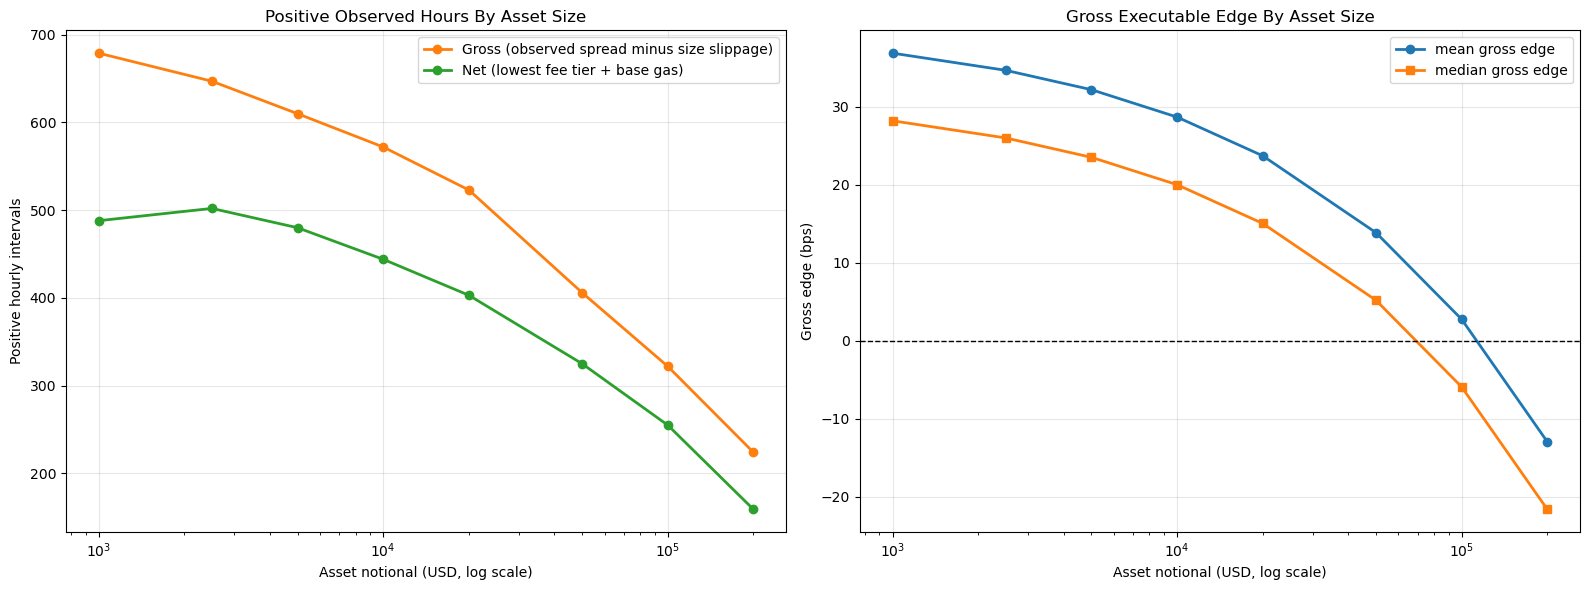

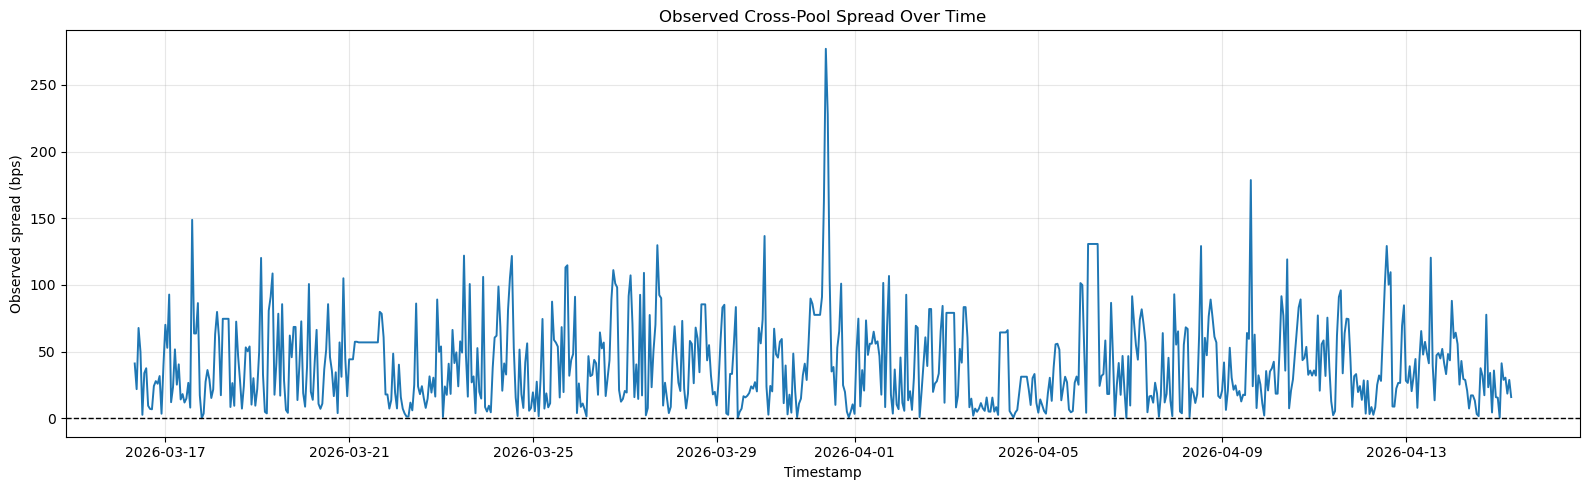

Most supportive observed trade size: **$2,500** with **502** net-positive hourly intervals and mean net edge of **22.71 bps**.

In [5]:
if real_size_sensitivity.empty:
    raise RuntimeError('No real size-sensitivity data was built. Check the selected pools and fetched OHLCV rows above.')

display(real_size_sensitivity.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['gross_positive_intervals'],
    marker='o',
    linewidth=2,
    label='Gross (observed spread minus size slippage)',
    color='#ff7f0e',
)
axes[0].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['net_positive_intervals'],
    marker='o',
    linewidth=2,
    label='Net (lowest fee tier + base gas)',
    color='#2ca02c',
)
axes[0].set_xscale('log')
axes[0].set_title('Positive Observed Hours By Asset Size')
axes[0].set_xlabel('Asset notional (USD, log scale)')
axes[0].set_ylabel('Positive hourly intervals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['mean_gross_edge_bps'],
    marker='o',
    linewidth=2,
    label='mean gross edge',
)
axes[1].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['median_gross_edge_bps'],
    marker='s',
    linewidth=2,
    label='median gross edge',
)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_title('Gross Executable Edge By Asset Size')
axes[1].set_xlabel('Asset notional (USD, log scale)')
axes[1].set_ylabel('Gross edge (bps)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(market_edges['timestamp'], market_edges['observed_spread_bps'], linewidth=1.4, color='#1f77b4')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Observed Cross-Pool Spread Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Observed spread (bps)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_net_row = real_size_sensitivity.sort_values(
    ['net_positive_intervals', 'mean_net_edge_bps', 'asset_notional_usd'],
    ascending=[False, False, True],
).iloc[0]

if best_net_row['net_positive_intervals'] > 0 and best_net_row['mean_net_edge_bps'] > 0:
    display(Markdown(
        f"Most supportive observed trade size: **${best_net_row['asset_notional_usd']:,.0f}** "
        f"with **{int(best_net_row['net_positive_intervals'])}** net-positive hourly intervals "
        f"and mean net edge of **{best_net_row['mean_net_edge_bps']:.2f} bps**."
    ))
elif best_net_row['net_positive_intervals'] > 0:
    display(Markdown(
        f"Most permissive observed trade size: **${best_net_row['asset_notional_usd']:,.0f}** "
        f"with **{int(best_net_row['net_positive_intervals'])}** net-positive hourly intervals, "
        f"but the average modeled net edge is still **{best_net_row['mean_net_edge_bps']:.2f} bps**. "
        "That means the strategy only works in selective observed spread windows under the current assumptions."
    ))
else:
    display(Markdown(
        "No asset-size bucket remains net positive under the current real pool dataset and cost assumptions. "
        "That does not prove the market is impossible, but it does mean the current screen is not supportive yet."
    ))


## Suggested Next Step

If this notebook still looks promising after you adjust the assumptions, the next build step is to fork the main pipeline into a dedicated implementation notebook for `optimism_wbtc_weth` with separate raw, curated, and report directories. That avoids mixing artifacts from the existing Ethereum `WBTC/WETH` run with the new market.